DATA VISUALIZATION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
import matplotlib.ticker as ticker
import plotly.express as px
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ncr_ride_bookings.csv')
df.head(5)

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [3]:
df['Reason for cancelling by Customer'] = df['Reason for cancelling by Customer'].replace('0', 'Unknow')
df['Driver Cancellation Reason'] = df['Driver Cancellation Reason'].replace('0', 'Unknow')
df['Incomplete Rides Reason'] = df['Incomplete Rides Reason'].replace('0', 'Unknow')
df['Payment Method'] = df['Payment Method'].replace('0', 'Unknow')
df['Avg VTAT'] = df['Avg VTAT'].fillna(0)
df['Avg CTAT'] = df['Avg CTAT'].fillna(0)
df['Cancelled Rides by Customer'] = df['Cancelled Rides by Customer'].fillna(0)
df['Cancelled Rides by Driver'] = df['Cancelled Rides by Driver'].fillna(0)
df['Incomplete Rides'] = df['Incomplete Rides'].fillna(0)
df['Booking Value'] = df['Booking Value'].fillna(0)
df['Ride Distance'] = df['Ride Distance'].fillna(0)
df['Driver Ratings'] = df['Driver Ratings'].fillna(0)
df['Customer Rating'] = df['Customer Rating'].fillna(0)

In [4]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')
df['Booking ID'] = df['Booking ID'].astype('string')
df['Booking Status'] = df['Booking Status'].astype('string')
df['Customer ID'] = df['Customer ID'].astype('string')
df['Vehicle Type'] = df['Vehicle Type'].astype('string')
df['Pickup Location'] = df['Pickup Location'].astype('string')
df['Drop Location'] = df['Drop Location'].astype('string')
df['Driver Cancellation Reason'] = df['Driver Cancellation Reason'].astype('string')
df['Cancelled Rides by Customer'] = df['Cancelled Rides by Customer'].astype('int')
df['Reason for cancelling by Customer'] = df['Reason for cancelling by Customer'].astype('string')
df['Cancelled Rides by Driver'] = df['Cancelled Rides by Driver'].astype('int')
df['Driver Cancellation Reason'] = df['Driver Cancellation Reason'].astype('string')
df['Incomplete Rides'] = df['Incomplete Rides'].astype('int')
df['Incomplete Rides Reason'] = df['Incomplete Rides Reason'].astype('string')
df['Booking Value'] = df['Booking Value'].astype('int')
df['Payment Method'] = df['Payment Method'].astype('string')

In [5]:
df.head(5)

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,2025-10-18 12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,0.0,0.0,...,<NA>,0,<NA>,0,<NA>,0,0.00,0.0,0.0,<NA>
1,2024-11-29,2025-10-18 18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,<NA>,0,<NA>,1,Vehicle Breakdown,237,5.73,0.0,0.0,UPI
2,2024-08-23,2025-10-18 08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,<NA>,0,<NA>,0,<NA>,627,13.58,4.9,4.9,Debit Card
3,2024-10-21,2025-10-18 17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,<NA>,0,<NA>,0,<NA>,416,34.02,4.6,5.0,UPI
4,2024-09-16,2025-10-18 22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,<NA>,0,<NA>,0,<NA>,737,48.21,4.1,4.3,UPI


In [6]:
df['day_week'] = df['Date'].dt.dayofweek
df['day_week_name'] = df['Date'].dt.day_name()
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')
df['hour'] = df['Time'].dt.hour
df.head(5)

pivot = df.groupby(['day_week', 'day_week_name', 'hour'])['Booking ID'].nunique().reset_index()
pivot = pivot.pivot(index='day_week', columns='hour', values='Booking ID').fillna(0)


day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot.index = [pd.to_datetime(str(2024) + '-01-0' + str(i+1)).day_name() for i in pivot.index]
pivot = pivot.reindex(day_order).fillna(0)

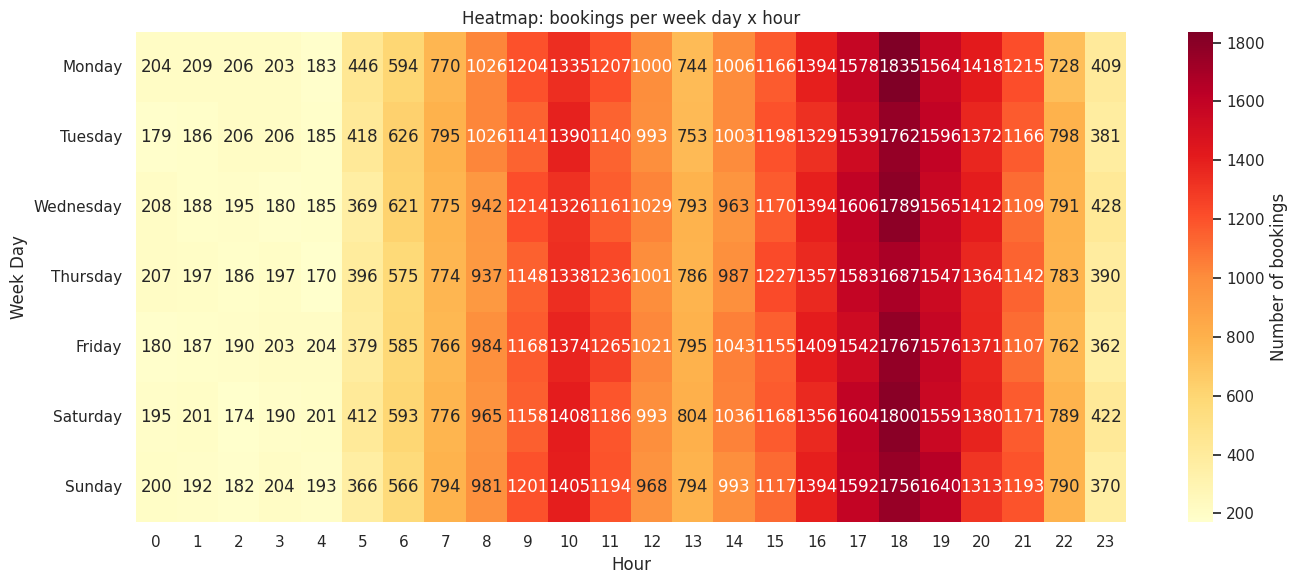

In [7]:
plt.figure(figsize=(14,6))
sns.set_theme(style='white')
ax = sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Number of bookings'})
ax.set_title('Heatmap: bookings per week day x hour')
ax.set_xlabel('Hour')
ax.set_ylabel('Week Day')
plt.tight_layout()
plt.savefig('heatmap_hour_day.png', dpi=150)
plt.show()

In [8]:
df['Driver Cancellation Reason'].value_counts()

,count
Driver Cancellation Reason,
Customer related issue,6837
The customer was coughing/sick,6751
Personal & Car related issues,6726
More than permitted people in there,6686


In [9]:
df['Reason for cancelling by Customer'].value_counts()

,count
Reason for cancelling by Customer,
Wrong Address,2362
Change of plans,2353
Driver is not moving towards pickup location,2335
Driver asked to cancel,2295
AC is not working,1155


In [10]:
df['Group of Reasons'] = df['Driver Cancellation Reason'].fillna('') + df['Reason for cancelling by Customer'].fillna('')
df['Group of Reasons'] = df['Group of Reasons'].replace('', 'Unknown')
df['Group of Reasons'].value_counts()
temp_data = df[df['Group of Reasons'] != 'Unknown']
# Idenfying who is responsible for the cancellation
df['Cancelled by'] = temp_data.apply(
    lambda x: 'Customer' if pd.notna(x['Reason for cancelling by Customer'])
    else 'Driver',
    axis = 1
)

temp_data = df[df['Group of Reasons'] != 'Unknown']

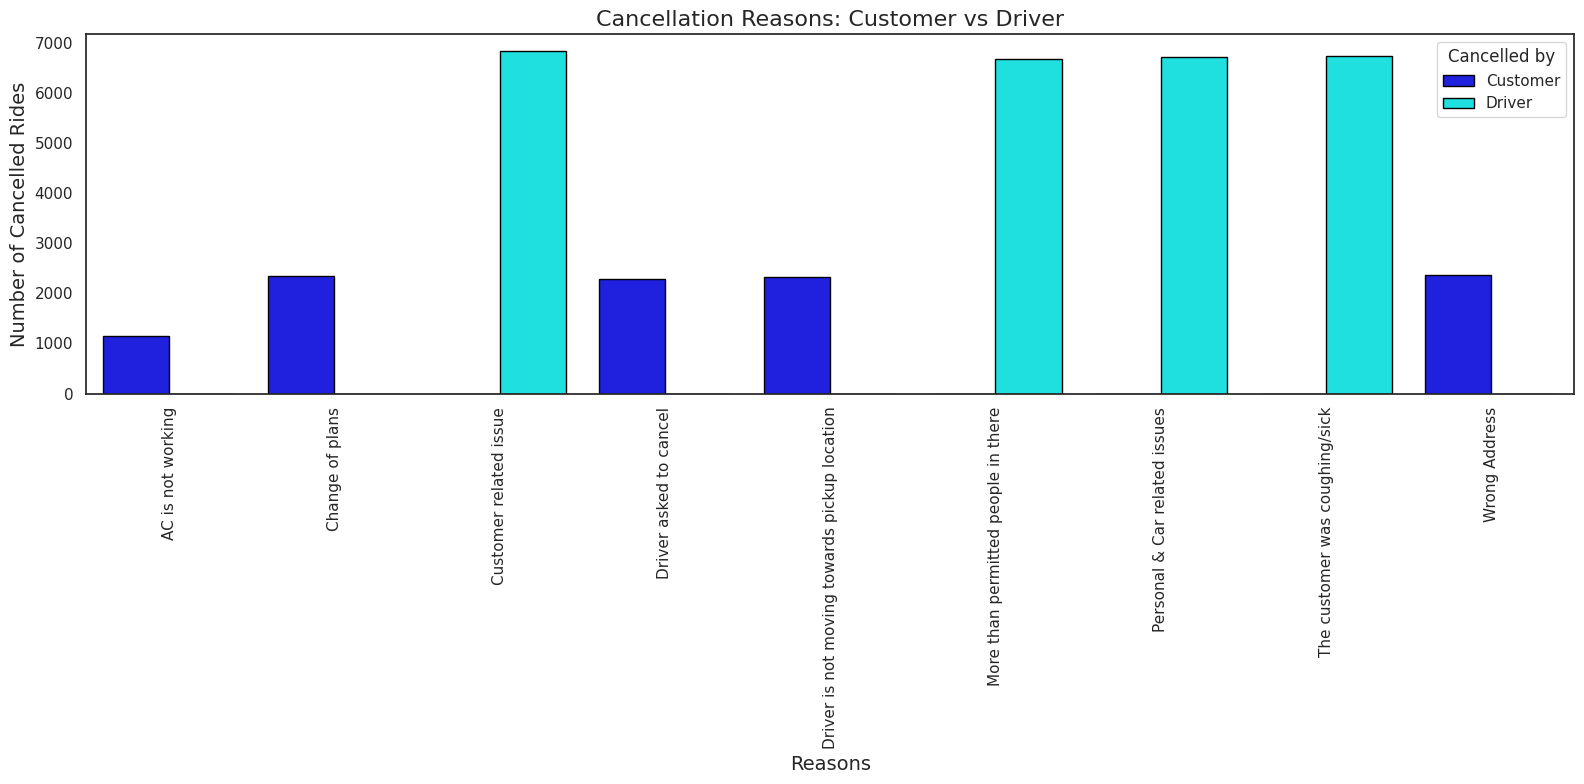

In [11]:

grouped_data = df.groupby(['Group of Reasons', 'Cancelled by']).size().unstack().fillna(0).astype(int)
grouped_data = grouped_data.reset_index()
grouped_data = grouped_data.melt(
    id_vars='Group of Reasons',
    var_name='Cancelled by',
    value_name='Number of Cancelled Rides'
)

plt.figure(figsize=(16, 8))
sns.set_theme(style='white')

ax = sns.barplot(
    data=grouped_data,
    x='Group of Reasons',
    y='Number of Cancelled Rides',
    hue='Cancelled by',
    palette=['blue', 'cyan'],
    edgecolor='black'
)

plt.title('Cancellation Reasons: Customer vs Driver', fontsize=16)
plt.ylabel('Number of Cancelled Rides', fontsize=14)
plt.xlabel('Reasons', fontsize=14)
plt.legend(title='Cancelled by', loc='upper right')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('barplot_Cancellation_Reasons_with_edges.png', dpi=150)
plt.show()

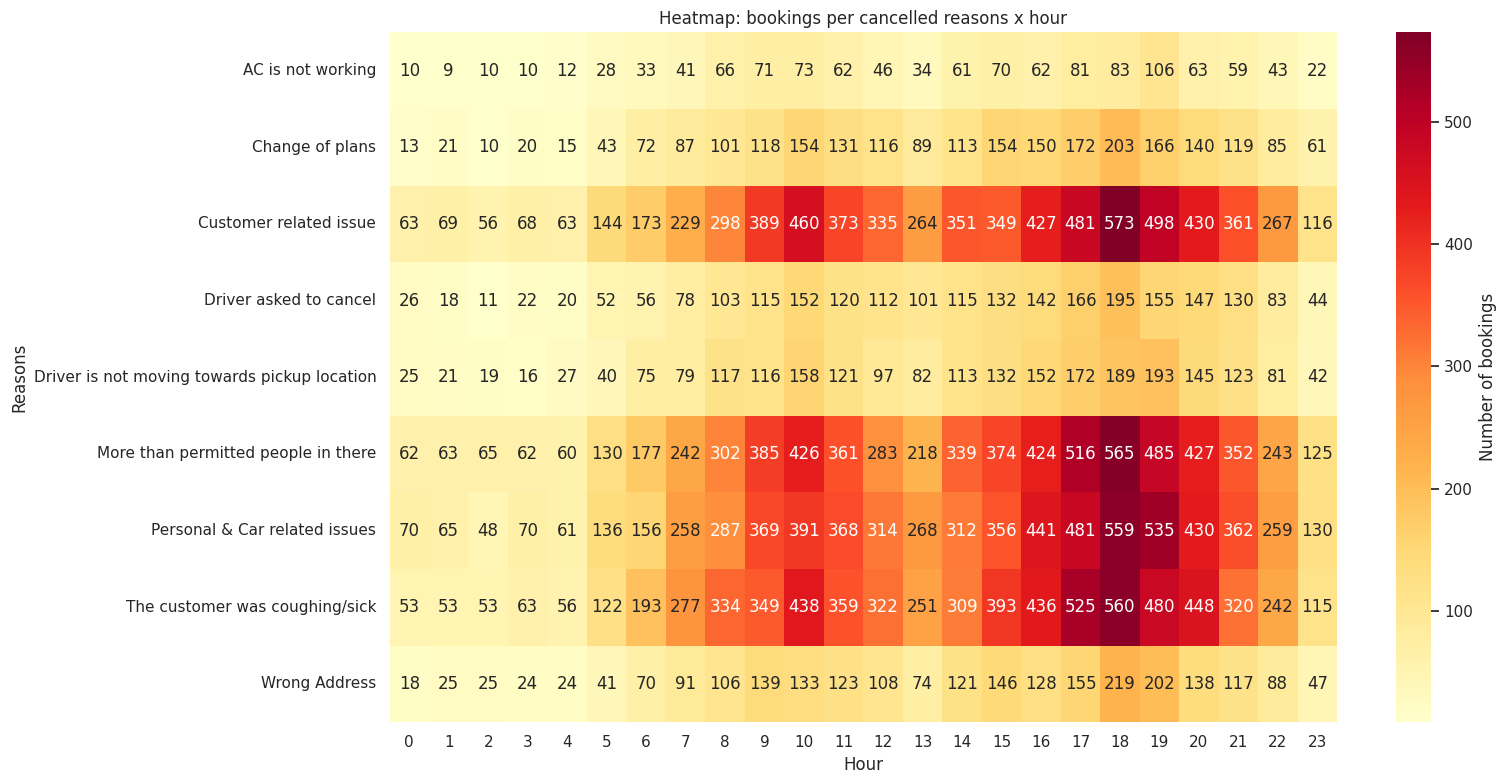

In [12]:
pivot = temp_data.groupby(['Group of Reasons', 'Cancelled by', 'hour'])['Booking ID'].nunique().reset_index()
pivot = pivot.pivot(index='Group of Reasons', columns='hour', values='Booking ID').fillna(0)

plt.figure(figsize=(16, 8))
sns.set_theme(style='white')
ax = sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Number of bookings'})
ax.set_title('Heatmap: bookings per cancelled reasons x hour')
ax.set_xlabel('Hour')
ax.set_ylabel('Reasons')
plt.tight_layout()
plt.savefig('heatmap_hour_reasons.png', dpi=150)
plt.show()

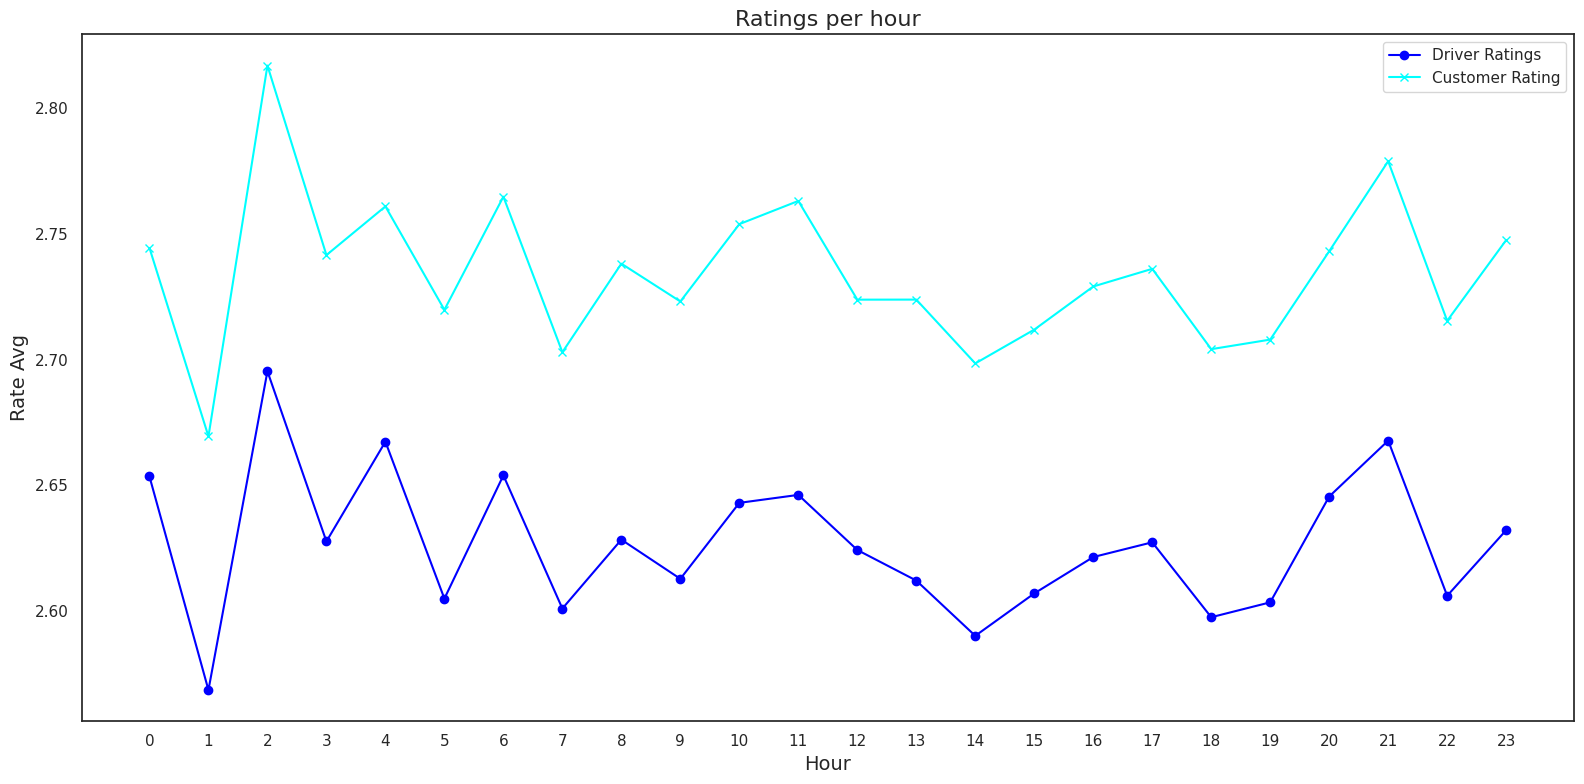

In [13]:
driver_rate_by_hour = df.groupby('hour')['Driver Ratings'].mean()
customer_rate_by_hour = df.groupby('hour')['Customer Rating'].mean()

plt.figure(figsize=(16, 8))
plt.plot(driver_rate_by_hour, label='Driver Ratings', color='blue', marker='o')
plt.plot(customer_rate_by_hour, label='Customer Rating', color='cyan', marker='x')
plt.title('Ratings per hour', fontsize=16)
plt.xlabel('Hour', fontsize=14)
plt.ylabel('Rate Avg', fontsize=14)
plt.legend(loc='upper right')
plt.xticks(range(24))  # Exibir todas as horas
plt.tight_layout()
plt.savefig('ratings_by_hour.png', dpi=150)
plt.show()